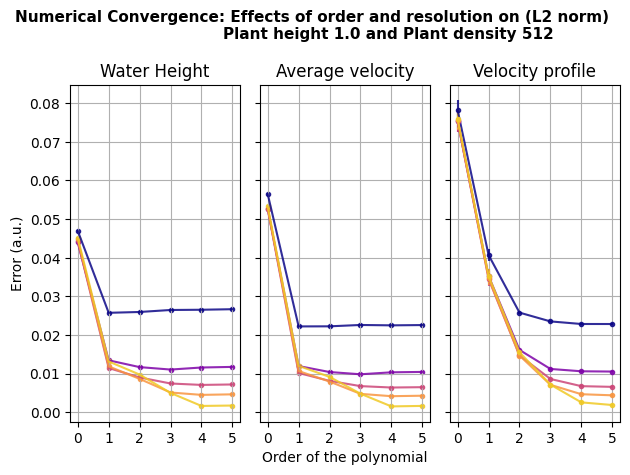

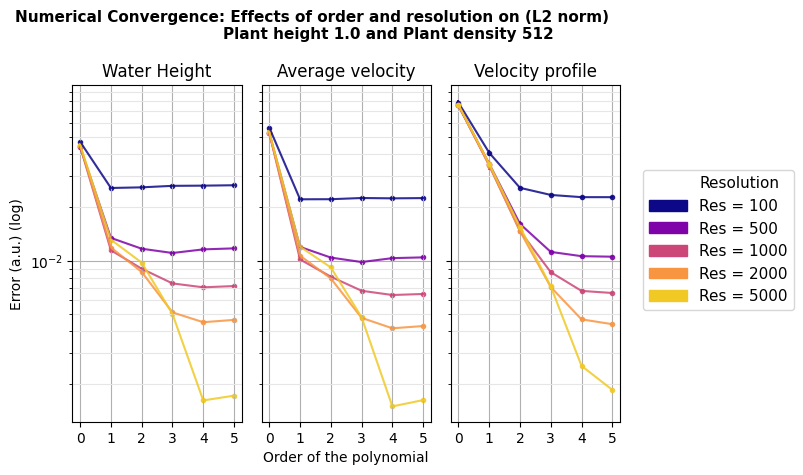

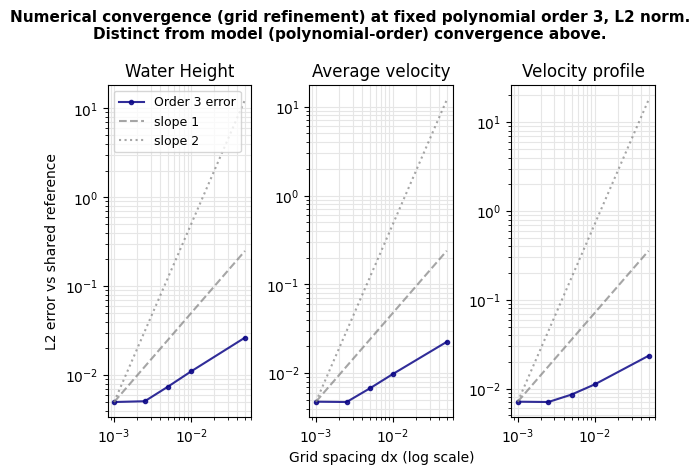

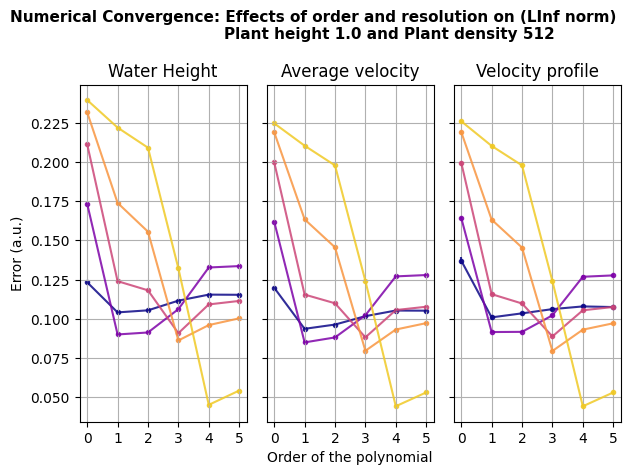

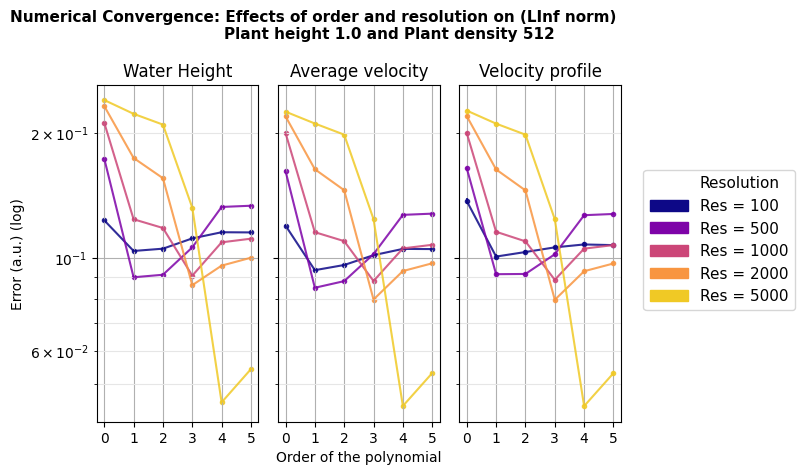

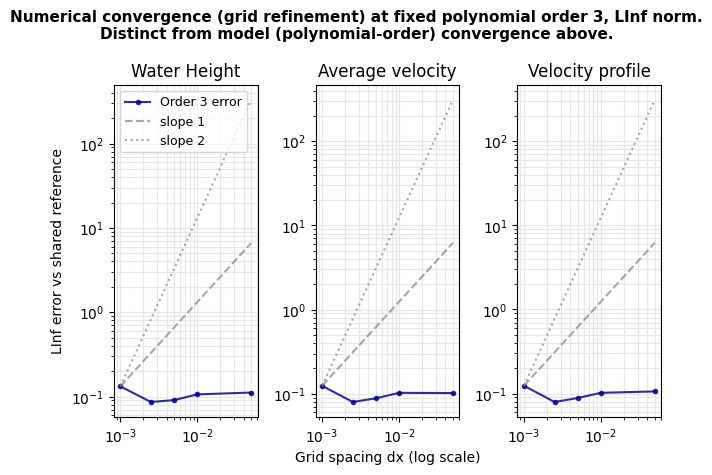

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import matplotlib.ticker as ticker
from pathlib import Path
from itertools import product


SAVE_FIG = True

# Order used for the numerical (grid-refinement) convergence plot
NUMERICAL_CONVERGENCE_ORDER = 3

results_dir = Path(os.getcwd()) / "Data-processing/Results/Omar/"
data_path = results_dir / "clanker_made"
out_graph_path = results_dir / "clanker_made/graphs"
out_graph_path.mkdir(parents=True, exist_ok=True)
out_table_path = results_dir / "clanker_made/tables"
out_table_path.mkdir(parents=True, exist_ok=True)

data = pd.read_csv(data_path / "01-data-damBreakNoVelocity.csv")
time = pd.read_csv(data_path / "02-time-damBreakNoVelocity.csv")
profile = pd.read_csv(data_path / "03-u_profile-damBreakNoVelocity.csv", low_memory=False)
error = pd.read_csv(data_path / "04-error-damBreakNoVelocity.csv")

# Order 6 is the same order as the reference itself, so its "error" reflects
# grid discretization, not model (polynomial-order) convergence -- drop it
# from every plot. Order 5 is now the highest order shown; it's still flagged
# in the data via "Reference Contaminated" near the top of the sweep
# resolutions (where it sits close enough to the reference to be
# untrustworthy), but that flag is no longer drawn differently in the plots.
REFERENCE_ORDER = 6
error = error.loc[error["Order"] != REFERENCE_ORDER]

# information
index_columns = set(time.columns[0:-1])
quantity_columns = [
            set(data.columns) - index_columns, 
            set(time.columns) - index_columns,
            set(error.columns) - index_columns
        ]
index_columns = list(index_columns)
quantity_columns = [sorted(list(i)) for i in quantity_columns]

# Aesthetic
def marker_list_func(palette=None):
    markers = ['circle', 'square', 'triangle-up', 'diamond', 'star', 'hexagon']
    markers_1 = [".", "s", "o", "*"]
    return markers
def marker_map_func(quantity_list: list, marke_list: str = None): 

    marker_list = marker_list_func()

    if len(marker_list) < len(quantity_list):
        print("WARNING: Color palette is smaller than quantity to represent. Repeated colours will be used.")
    
    return {quant: marker_list[i % len(marker_list)] for i, quant in enumerate(quantity_list)}

def color_list_func(palette=None):
    color_blind_colors = ['#56B4E9', '#D55E00', '#009E73', '#CC79A7', '#E69F00']
    old_palette = ['#ffd700', '#0000ff', '#ea5f94', '#ffb14e', '#fa8775','#009E73']
    plasma = ["#0D0887", "#7E03A8","#CC4678", "#F89540",  "#F0C925", "#E6A800"]
    return plasma
def color_map_func(quantity_list: list, palette: str = None): 

    color_list = color_list_func()

    if len(color_list) < len(quantity_list):
        print("WARNING: Color palette is smaller than quantity to represent. Repeated colours will be used.")
    
    return {quant: color_list[i % len(color_list)] for i, quant in enumerate(quantity_list)}

# Plots
def legend_plot_convergence(fig, color_map: dict):
    """
    Creates a single legend specifying what color is linked to what resolution.
    """
    color_handles = []
    for res, color in color_map.items():
        handle = mpatches.Patch(color=color, label=f"Res = {int(res)}")
        color_handles.append(handle)

    fig.legend(
        handles=[
            mlines.Line2D([], [], color='none', label='Resolution'),    # header
            *color_handles,
        ],
        loc='center left',    # places legend to the right of all subplots
        bbox_to_anchor = (1.0, 0.5),
        frameon=True,
        fontsize=11,
        handlelength=2.5,
    )

def plot_error_convergence(df: pd.DataFrame, 
                            error_type: str = "L2", 
                            ax_type: str = "linear", 
                            alpha: float = 0.85,
                        ):

    fig, axs = plt.subplots(1, 3, sharey=True)

    resolutions = df["Resolution"].unique()
    orders = df.loc[df["Order"]<6, "Order"].unique()

    color_map = color_map_func(resolutions)

    for resolution in resolutions:

        mask = (df["Resolution"] == resolution) & (df["Error Type"] == error_type)
        sub = df.loc[mask].sort_values("Order")

        axs[0].plot(sub["Order"], sub["Water Height"], linestyle='-',
                    color=color_map[resolution], alpha=alpha)
        axs[0].scatter(sub["Order"], sub["Water Height"],
                        color=color_map[resolution], marker=".", alpha=alpha)

        axs[1].plot(sub["Order"], sub["Average Velocity"], linestyle='-',
                    color=color_map[resolution], alpha=alpha)
        axs[1].scatter(sub["Order"], sub["Average Velocity"],
                        color=color_map[resolution], marker=".", alpha=alpha)

        axs[2].errorbar(sub["Order"], sub["U profile"],
                        yerr=sub["std U profile"],
                        color=color_map[resolution],
                        marker=".", alpha=alpha)

        axs[0].set_title("Water Height")
        axs[1].set_title("Average velocity")
        axs[2].set_title("Velocity profile")
        if ax_type == "log":
            axs[0].set_ylabel("Error (a.u.) (log)")
        else:
            axs[0].set_ylabel("Error (a.u.)")
        axs[1].set_xlabel("Order of the polynomial")

    for ax in axs.flatten():
        ax.grid()
        ax.grid(which="minor", color="0.9")
        ax.set_xticks(range(0, 6))
        if ax_type == "log":
            ax.set_yscale("log")

    fig.suptitle(
                f"""Numerical Convergence: Effects of order and resolution on ({error_type} norm) 
                            Plant height {height} and Plant density {density}""", 
                fontsize=11, fontweight='bold'
            )
    
    return fig, axs, color_map

def plot_percentage_change_convergence(df: pd.DataFrame, 
                                        error_type: str = "L2", 
                                        ax_type: str = "linear",
                                        include_zero: bool = False,
                                        alpha: float = 0.85,
                                    ):

    pct_df = compute_percentage_change(df, error_type=error_type, include_zero=include_zero)
    
    fig, axs = plt.subplots(1, 3, sharey=True)

    resolutions = pct_df["Resolution"].unique()
    orders = np.sort(pct_df["Order"].unique())
    color_map = color_map_func(resolutions)

    for resolution in resolutions:
        mask = pct_df["Resolution"] == resolution
        sub = pct_df.loc[mask].sort_values("Order")

        axs[0].plot(sub["Order"], sub["Water Height"], linestyle='-', color=color_map[resolution], alpha=alpha)
        axs[0].scatter(sub["Order"], sub["Water Height"], color=color_map[resolution], marker=".", alpha=alpha)

        axs[1].plot(sub["Order"], sub["Average Velocity"], linestyle='-', color=color_map[resolution], alpha=alpha)
        axs[1].scatter(sub["Order"], sub["Average Velocity"], color=color_map[resolution], marker=".", alpha=alpha)

        axs[2].plot(sub["Order"], sub["U profile"], linestyle='-', color=color_map[resolution], alpha=alpha)
        axs[2].scatter(sub["Order"], sub["U profile"], color=color_map[resolution], marker=".", alpha=alpha)

    axs[0].set_title("Water Height")
    axs[1].set_title("Average velocity")
    axs[2].set_title("Velocity profile")
    axs[0].set_ylabel("Relative error change (% compared to previous order)")
    axs[1].set_xlabel("Order of the polynomial")

    for ax in axs.flatten():
        ax.grid()
        ax.grid(which="minor", color="0.9")
        ax.set_xticks(range(0, 6))
        if ax_type == "log":
            ax.set_yscale("log")
            ax.set_xscale("log")

    fig.suptitle(
        f"""Percentage in error reduction ({error_type} norm) compared to previous order.
                    Plant height {height} and Plant density {density}""",
        fontsize=11, fontweight='bold'
    )
    return fig, axs, color_map

def compute_percentage_change(df: pd.DataFrame,
                               error_type: str,
                               group_cols: list = ["Resolution"],
                               quantities: list = ["Water Height", "Average Velocity", "U profile"],
                               include_zero: bool = False,
                               ) -> pd.DataFrame:
    """
    Computes (new - old) / new * 100 between consecutive polynomial orders,
    for each group in `group_cols`, for a single error_type.

    Returns a long-format DataFrame with columns:
        group_cols + ["Order"] + quantities
    where "Order" is the *new* order in each comparison (old = Order - 1's
    neighbor in the sorted, available order list -- not literally Order-1,
    in case some orders are missing).
    """
    sub = df.loc[df["Error Type"] == error_type]

    records = []
    for keys, group in sub.groupby(group_cols):
        keys = keys if isinstance(keys, tuple) else (keys,)
        group = group.sort_values("Order")

        orders = group["Order"].to_numpy()
        values = group[quantities].to_numpy()
        contaminated_flags = group["Reference Contaminated"].to_numpy()

        for i in range(0, len(orders)):
            if (not include_zero) & (i == 0):
                continue
            elif (include_zero) & (i == 0):
                pct = np.zeros_like(values[0])
            else:
                old_vals, new_vals = values[i - 1], values[i]
                pct = (new_vals - old_vals) / old_vals * 100

            record = dict(zip(group_cols, keys))
            record["Order"] = orders[i]
            # Flagged when the "new" order's own error is reference-contaminated,
            # since the % change is computed from that (untrustworthy) value.
            record["Reference Contaminated"] = bool(contaminated_flags[i])
            record.update(dict(zip(quantities, pct)))
            records.append(record)

    return pd.DataFrame(records)


def plot_percentage_cumulative_convergence(df: pd.DataFrame, 
                                        error_type: str = "L2",
                                        plot_type: str = "lines",
                                        baseline_order: int = 0,
                                        alpha: float = 0.85,
                                    ):

    pct_df = compute_cumulative_improvement(df, error_type=error_type)
    
    fig, axs = plt.subplots(1, 3, sharey=True)

    resolutions = pct_df["Resolution"].unique()
    orders = np.sort(pct_df["Order"].unique())
    color_map = color_map_func(resolutions)

    for i, resolution in enumerate(resolutions):
        mask = pct_df["Resolution"] == resolution
        group = pct_df.loc[mask].sort_values("Order")

        if plot_type == "bars":
            bar_width = 0.8 / len(resolutions)
            # offset each resolution's bars so they sit side-by-side per order
            x_positions = group["Order"].to_numpy() + (i - (len(resolutions) - 1) / 2) * bar_width

            axs[0].bar(x_positions, group["Water Height"], width=bar_width,
                       color=color_map[resolution], label=resolution)
            axs[1].bar(x_positions, group["Average Velocity"], width=bar_width,
                       color=color_map[resolution])
            axs[2].bar(x_positions, group["U profile"], width=bar_width,
                       color=color_map[resolution])
        elif plot_type == "lines":
            axs[0].plot(group["Order"], group["Water Height"], linestyle='-', color=color_map[resolution], alpha=alpha)
            axs[0].scatter(group["Order"], group["Water Height"], color=color_map[resolution], marker=".", alpha=alpha)

            axs[1].plot(group["Order"], group["Average Velocity"], linestyle='-', color=color_map[resolution], alpha=alpha)
            axs[1].scatter(group["Order"], group["Average Velocity"], color=color_map[resolution], marker=".", alpha=alpha)

            axs[2].plot(group["Order"], group["U profile"], linestyle='-', color=color_map[resolution], alpha=alpha)
            axs[2].scatter(group["Order"], group["U profile"], color=color_map[resolution], marker=".", alpha=alpha)

    axs[0].set_title("Water Height")
    axs[1].set_title("Average velocity")
    axs[2].set_title("Velocity profile")
    axs[0].set_ylabel(f"% error change compared to depth averaging (order 0)")
    axs[1].set_xlabel("Order of the polynomial")

    for ax in axs.flatten():
        ax.set_xticks(range(0, 6))


    fig.suptitle(
        f"""% Error reduction compared to depth averaged soluton ({error_type} norm) 
                    Plant height {height} and Plant density {density}""",
        fontsize=11, fontweight='bold'
    )
    return fig, axs, color_map
def compute_cumulative_improvement(df: pd.DataFrame,
                                    error_type: str = "L2",
                                    baseline_order: int = 0,
                                    group_cols: list = ["Resolution"],
                                    quantities: list = ["Water Height", "Average Velocity", "U profile"]
                                ) -> pd.DataFrame:
    """
    # For each group, computes percentage improvement of every order
    # relative to a fixed baseline order (default: order 0):
    #     (baseline - value) / baseline * 100
    # Positive = improvement over the baseline. Baseline order itself
    # is included with 0% by definition (and can be dropped by the caller
    # if not needed).
    """
    sub = df.loc[df["Error Type"] == error_type]

    records = []
    for keys, group in sub.groupby(group_cols):
        keys = keys if isinstance(keys, tuple) else (keys,)
        group = group.sort_values("Order")

        baseline_row = group.loc[group["Order"] == baseline_order]
        if baseline_row.empty:
            continue  # this group has no order-0 case to compare against

        baseline_vals = baseline_row[quantities].to_numpy()[0]

        for _, row in group.iterrows():
            vals = row[quantities].to_numpy()
            improvement = (vals - baseline_vals) / baseline_vals * 100

            record = dict(zip(group_cols, keys))
            record["Order"] = row["Order"]
            record["Reference Contaminated"] = bool(row["Reference Contaminated"])
            record.update(dict(zip(quantities, improvement)))
            records.append(record)

    return pd.DataFrame(records)


def plot_numerical_convergence(df: pd.DataFrame,
                                order: int = 2,
                                error_type: str = "L2",
                                alpha: float = 0.85,
                            ):
    """
    Numerical (grid-refinement) convergence at a FIXED polynomial order --
    distinct from the model (polynomial-order) convergence plots above.
    x-axis: dx (log). y-axis: error against the single shared reference (log).
    Reference slope-1 and slope-2 lines are overlaid so the observed order of
    accuracy p can be read off. Returns (fig, axs, observed_slopes) where
    observed_slopes is {quantity: p}, computed between the two finest grids.
    """
    sub = df.loc[
        (df["Order"] == order) &
        (df["Error Type"] == error_type) &
        (~df["Reference Contaminated"])
    ].sort_values("dx")

    if sub.empty:
        raise ValueError(f"No numerical-convergence data for order={order}, error_type={error_type}")

    fig, axs = plt.subplots(1, 3, sharex=True)
    quantities = ["Water Height", "Average Velocity", "U profile"]
    titles = ["Water Height", "Average velocity", "Velocity profile"]
    color = color_list_func()[0]

    dx = sub["dx"].to_numpy()
    observed_slopes = {}

    for ax, quantity, title in zip(axs, quantities, titles):
        y = sub[quantity].to_numpy()
        ax.plot(dx, y, linestyle='-', marker=".", color=color, alpha=alpha,
                label=f"Order {order} error" if quantity == "Water Height" else None)

        # Reference slopes of 1 and 2, anchored at the coarsest point, so the
        # observed order p can be read off by eye against the data curve.
        anchor_dx, anchor_y = dx[0], y[0]
        for p, style in [(1, "--"), (2, ":")]:
            slope_y = anchor_y * (dx / anchor_dx) ** p
            ax.plot(dx, slope_y, linestyle=style, color="0.5", alpha=0.7,
                    label=f"slope {p}" if quantity == "Water Height" else None)

        observed_slopes[quantity] = np.log(y[-2] / y[-1]) / np.log(dx[-2] / dx[-1])

        ax.set_title(title)
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.grid(which="both", color="0.9")

    axs[0].set_ylabel(f"{error_type} error vs shared reference")
    axs[1].set_xlabel("Grid spacing dx (log scale)")
    axs[0].legend(fontsize=9)

    fig.suptitle(
        f"Numerical convergence (grid refinement) at fixed polynomial order {order}, "
        f"{error_type} norm.\nDistinct from model (polynomial-order) convergence above.",
        fontsize=11, fontweight='bold'
    )
    return fig, axs, observed_slopes

# Simulations for convergence have resolution up to the finest tested resolution
# (the reference's own resolution never appears in `error` -- see
# data_formatter.py -- so this adapts automatically to whichever resolution is
# currently REFERENCE_RESOLUTION there).
# Find those
mask_res = error["Resolution"] == error["Resolution"].max()
idx_res = error.loc[mask_res].index

heights = error.loc[idx_res, "Plant Height"].unique()
densities = error.loc[idx_res, "Plant Density"].unique()
mask_h = error["Plant Height"].isin(heights)
mask_dens = error["Plant Density"].isin(densities)

convergence_arr = error.loc[(mask_h) & (mask_dens)]

observed_slopes_report = []

for density, height in product(densities, heights):
    mask = (convergence_arr["Plant Height"]==height) & (convergence_arr["Plant Density"]==density)

    errors_available = convergence_arr['Error Type'].unique()

    for error_type in errors_available:
        # Error in absolute terms

        fig_error_linear, axs_error_linear, cm_error_linear = plot_error_convergence(df=convergence_arr.loc[mask], error_type=error_type)
        # legend_plot_convergence(fig_error_linear, color_map=cm_error_linear)
        fig_error_linear.tight_layout()

        fig_error_log, axs_error_log, cm_error_log = plot_error_convergence(df=convergence_arr.loc[mask], error_type=error_type, ax_type="log")
        legend_plot_convergence(fig_error_log, color_map=cm_error_log)
        fig_error_log.tight_layout()

        # fig_rel_err, axs_rel_err, cm_rel_err = plot_percentage_change_convergence(df=convergence_arr.loc[mask], error_type=error_type, include_zero=True)
        # legend_plot_convergence(fig_rel_err, color_map=cm_rel_err)
        # fig_rel_err.tight_layout()

        # fig_cum_err, axs_cum_err, cm_cum_err = plot_percentage_cumulative_convergence(df=convergence_arr.loc[mask], error_type=error_type)
        # legend_plot_convergence(fig_cum_err, color_map=cm_cum_err)
        # fig_cum_err.tight_layout()

        fig_num_conv, axs_num_conv, observed_slopes = plot_numerical_convergence(
            df=convergence_arr.loc[mask], order=NUMERICAL_CONVERGENCE_ORDER, error_type=error_type
        )
        fig_num_conv.tight_layout()

        observed_slopes_report.append({
            "Plant Density": density, "Plant Height": height,
            "Error Type": error_type, **observed_slopes,
        })
